# Лабораторная работа №3
## Обучение с учителем. Задача классификации

**Датасет:** Diabetes Health Indicators  
**Целевая переменная:** `Diabetes_012` — статус диабета у пациента (0 — нет диабета, 1 — предиабет, 2 — диабет 2 типа)  
**Тип задачи:** Мультиклассовая классификация (3 класса)


## Инициализация проекта

In [10]:
import datetime
import json
import time
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (
    train_test_split, 
    StratifiedKFold, 
    cross_val_score,
    GridSearchCV, 
    RandomizedSearchCV
)

from imblearn.over_sampling import SMOTE

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score, 
    f1_score, 
    precision_score, 
    recall_score, 
    confusion_matrix, 
    roc_auc_score, 
    roc_curve, 
    auc
)

from scipy.stats import loguniform, uniform, randint

import optuna

import joblib

from collections import Counter

warnings.filterwarnings('ignore')

## 1. Загрузка и подготовка данных

### 1.1. Загрузка датасета

In [11]:
data = pd.read_csv('../datasets/filtered_diabetes_health_indicators.csv')

### 1.2. Выделение целевого признака и предикторов

Целевой признак — `Diabetes_012`:
- **0** — нет диабета
- **1** — предиабет
- **2** — диабет 2 типа

Тип задачи: **мультиклассовая классификация** (3 класса).

In [12]:
y = data['Diabetes_012']
X = data.drop(columns=['Diabetes_012'])

### 1.3. Разделение на train/test (Hold-out со стратификацией)

In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, stratify=y, test_size=0.2)
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((183774, 21), (183774,), (45944, 21), (45944,))

### 1.4. Масштабирование признаков

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### 1.5. Балансировка классов (SMOTE)

Diabetes_012
0    189994
2     35095
1      4629
Name: count, dtype: int64


<Axes: ylabel='Diabetes_012'>

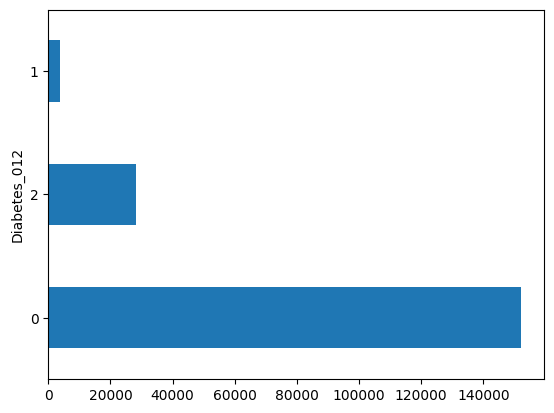

In [15]:
print(y.value_counts())
y_train.value_counts().plot.barh()

In [16]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

Diabetes_012
0    151995
1    151995
2    151995
Name: count, dtype: int64


<Axes: ylabel='Diabetes_012'>

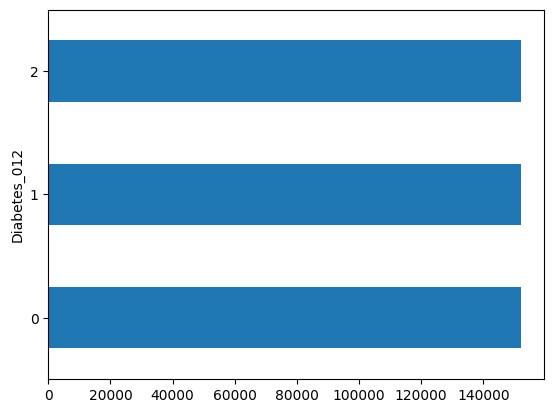

In [17]:
print(y_train_balanced.value_counts())
y_train_balanced.value_counts().plot.barh()

In [18]:
X_train, y_train = X_train_balanced, y_train_balanced
X_test = X_test_scaled

### 1.6. K-Fold (кросс-валидация)

In [19]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 1.7. Подвыборка для поиска гиперпараметров

После SMOTE train содержит большое количество объектов. Поиск гиперпараметров на полном объёме занял бы слишком много времени — выделяем подвыборку.

In [20]:
X_train_search, _, y_train_search, _ = train_test_split(
    X_train, y_train, train_size=0.05, random_state=42, stratify=y_train
)
print(f'Подвыборка для поиска гиперпараметров: {X_train_search.shape}')

Подвыборка для поиска гиперпараметров: (22799, 21)


## 2. Решение задачи классификации

### 2.1. Поиск гиперпараметров

In [21]:
def search_hyperparameters(model_name, method_search, X_train, y_train, param_grid, n_iter=15):
    start_time = time.time()
    
    m_name = model_name.lower()
    if m_name == 'logisticregression':
        model = LogisticRegression(max_iter=10000, random_state=42)
    elif m_name == 'knn':
        model = KNeighborsClassifier()
    elif m_name == 'naivebayes':
        model = GaussianNB()
    elif m_name == 'svm':
        model = SVC(probability=True, random_state=42)

    method = method_search.lower()
    
    if method == 'gridsearchcv':
        search = GridSearchCV(model, param_grid, cv=3, scoring='accuracy', n_jobs=-1)
        search.fit(X_train, y_train)
        res = {'best_params': search.best_params_, 'best_score': search.best_score_}

    elif method == 'randomizedsearchcv':
        search = RandomizedSearchCV(model, param_grid, n_iter=n_iter, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)
        search.fit(X_train, y_train)
        res = {'best_params': search.best_params_, 'best_score': search.best_score_}

    elif method == 'optuna':
        def objective(trial):
            params = {k: v(trial) for k, v in param_grid.items()}
            curr_model = model.set_params(**params)
            score = cross_val_score(curr_model, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
            return score.mean()

        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=n_iter)
        res = {'best_params': study.best_params, 'best_score': study.best_value}

    res['duration'] = time.time() - start_time
    return res

In [22]:
models = ['LogisticRegression', 'kNN', 'NaiveBayes', 'SVM']
methods = ['GridSearchCV', 'RandomizedSearchCV', 'Optuna']

parameters = {
    'LogisticRegression': {
        'GridSearchCV': {
            'C': [0.01, 0.1, 1, 10],
            'solver': ['lbfgs', 'saga'], 
            'penalty': ['l2']
        },
        'RandomizedSearchCV': {
            'C': loguniform(1e-2, 1e2),
            'solver': ['lbfgs', 'saga'],
            'penalty': ['l2']
        },
        'Optuna': {
            'C': lambda t: t.suggest_float('C', 1e-2, 1e2, log=True),
            'solver': lambda t: t.suggest_categorical('solver', ['lbfgs', 'saga']),
            'penalty': lambda t: t.suggest_categorical('penalty', ['l2'])
        }
    },
    'kNN': {
        'GridSearchCV': {'n_neighbors': [3, 5, 7, 9]},
        'RandomizedSearchCV': {'n_neighbors': randint(3, 15)},
        'Optuna': {
            'n_neighbors': lambda t: t.suggest_int('n_neighbors', 3, 15)
        }
    },
    'NaiveBayes': {
        'GridSearchCV': {'var_smoothing': [1e-9, 1e-8, 1e-7]},
        'RandomizedSearchCV': {'var_smoothing': loguniform(1e-10, 1e-5)},
        'Optuna': {'var_smoothing': lambda t: t.suggest_float('var_smoothing', 1e-10, 1e-5, log=True)}
    },
    'SVM': {
        'GridSearchCV': {
            'kernel': ['linear', 'rbf'],
            'C': [0.1, 1, 10]
        },
        'RandomizedSearchCV': {
            'kernel': ['linear', 'rbf'],
            'C': loguniform(1e-2, 1e2)
        },
        'Optuna': {
            'kernel': lambda t: t.suggest_categorical('kernel', ['linear', 'rbf']),
            'C': lambda t: t.suggest_float('C', 1e-2, 1e2, log=True)
        }
    }
}

In [23]:
best_params = {}

for model in models:
    best_params[model] = {}
    for method in methods:
        print(f"Поиск параметров для {model} методом {method}...", end=" ", flush=True)
        
        result = search_hyperparameters(
            model_name=model,
            method_search=method,
            X_train=X_train_search,
            y_train=y_train_search,
            param_grid=parameters[model][method],
            n_iter=15
        )
        
        best_params[model][method] = result
        print(f"Готово! Score: {result['best_score']:.4f}, Время: {result['duration']:.1f} сек.")

print("\nВсе гиперпараметры найдены.")

Поиск параметров для LogisticRegression методом GridSearchCV... Готово! Score: 0.5133, Время: 2.5 сек.
Поиск параметров для LogisticRegression методом RandomizedSearchCV... Готово! Score: 0.5133, Время: 0.9 сек.
Поиск параметров для LogisticRegression методом Optuna... Готово! Score: 0.5133, Время: 2.5 сек.
Поиск параметров для kNN методом GridSearchCV... Готово! Score: 0.6181, Время: 0.8 сек.
Поиск параметров для kNN методом RandomizedSearchCV... Готово! Score: 0.5890, Время: 2.8 сек.
Поиск параметров для kNN методом Optuna... Готово! Score: 0.6181, Время: 7.0 сек.
Поиск параметров для NaiveBayes методом GridSearchCV... Готово! Score: 0.4977, Время: 0.2 сек.
Поиск параметров для NaiveBayes методом RandomizedSearchCV... Готово! Score: 0.4977, Время: 0.3 сек.
Поиск параметров для NaiveBayes методом Optuna... Готово! Score: 0.4977, Время: 2.0 сек.
Поиск параметров для SVM методом GridSearchCV... Готово! Score: 0.6365, Время: 484.6 сек.
Поиск параметров для SVM методом RandomizedSearchCV.

In [24]:
rows = []
for model in models:
    for method in methods:
        rows.append({
            'Модель':  model,
            'Метод':   method,
            'Score':   f'{best_params[model][method]["best_score"]:.4f}',
            'Параметры': best_params[model][method]['best_params']
        })

pd.DataFrame(rows)

,Модель,Метод,Score,Параметры
0,LogisticRegression,GridSearchCV,0.5133,"{'C': 1, 'penalty': 'l2', 'solver': 'lbfgs'}"
1,LogisticRegression,RandomizedSearchCV,0.5133,"{'C': 2.481040974867813, 'penalty': 'l2', 'sol..."
2,LogisticRegression,Optuna,0.5133,"{'C': 0.5378126977481881, 'solver': 'lbfgs', '..."
3,kNN,GridSearchCV,0.6181,{'n_neighbors': 3}
4,kNN,RandomizedSearchCV,0.5890,{'n_neighbors': 5}
5,kNN,Optuna,0.6181,{'n_neighbors': 3}
6,NaiveBayes,GridSearchCV,0.4977,{'var_smoothing': 1e-09}
7,NaiveBayes,RandomizedSearchCV,0.4977,{'var_smoothing': 7.459343285726553e-09}
8,NaiveBayes,Optuna,0.4977,{'var_smoothing': 4.934013324781409e-06}
9,SVM,GridSearchCV,0.6365,"{'C': 10, 'kernel': 'rbf'}"


In [25]:
def convert(o):
    if isinstance(o, np.generic):
        return o.item()
    raise TypeError

with open('best_params.json', 'w') as f:
    json.dump(best_params, f, indent=4, default=convert)

In [26]:
with open('best_params.json', 'r') as f:
    best_params = json.load(f)

### 2.2 Обучение моделей на лучших параметрах

In [32]:
classes_list = np.unique(y_train)
y_test_bin = label_binarize(y_test, classes=classes_list)
n_classes = y_test_bin.shape[1]

In [33]:
def metrics(pred_array, prob_array=None, true_array=None):
    if true_array is None:
        true_array = y_test
        
    print(f"F1: {f1_score(true_array, pred_array, average='weighted'):.4f}")
    print(f"accuracy: {accuracy_score(true_array, pred_array):.4f}")
    print(f"precision: {precision_score(true_array, pred_array, average='weighted'):.4f}")
    print(f"recall: {recall_score(true_array, pred_array, average='weighted'):.4f}")
    
    if prob_array is not None:
        try:
            print(f"roc_auc_score: {roc_auc_score(true_array, prob_array, multi_class='ovr'):.4f}")
        except:
            print("roc_auc_score: не удалось рассчитать (проверьте формат prob_array)")
    else:
        print("roc_auc_score: N/A (вероятности не предоставлены)")

#### LogisticRegression

[19:49:51] Начало обучения Logistic Regression
[19:49:51] Модель обучена
F1: 0.6982
accuracy: 0.6211
precision: 0.8353
recall: 0.6211
roc_auc_score: 0.7524
Оценка кросс-валидации: 0.5187


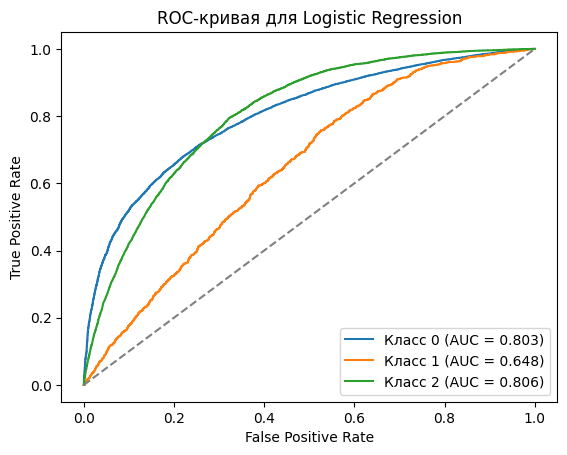

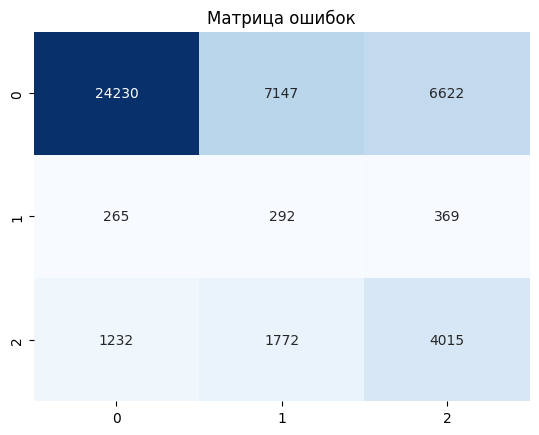

In [28]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Начало обучения Logistic Regression")
lr_cfg = best_params['LogisticRegression']['GridSearchCV']['best_params']
model_lr = LogisticRegression(max_iter=10000, random_state=42, **lr_cfg)

model_lr.fit(X_train, y_train)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Модель обучена")

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)

metrics(y_pred_lr, y_prob_lr)

scores_lr = cross_val_score(model_lr, X_train, y_train, cv=3, scoring='accuracy')
print(f'Оценка кросс-валидации: {scores_lr.mean():.4f}')

plt.figure()
for i in range(n_classes):
    fpr_lr, tpr_lr, _ = roc_curve(y_test_bin[:, i], y_prob_lr[:, i])
    roc_auc_lr = auc(fpr_lr, tpr_lr)
    plt.plot(fpr_lr, tpr_lr, label=f'Класс {i} (AUC = {roc_auc_lr:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для Logistic Regression')
plt.legend(loc='lower right')
plt.show()

cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure()
sns.heatmap(cm_lr, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

joblib.dump(model_lr, "logistic_regression_model.pkl")
model_lr = joblib.load("logistic_regression_model.pkl")

#### kNN

[19:49:52] Начало обучения kNN
[19:49:53] Модель kNN обучена
F1: 0.7047
accuracy: 0.6602
precision: 0.7753
recall: 0.6602
roc_auc_score: 0.6150
Оценка кросс-валидации: 0.8719


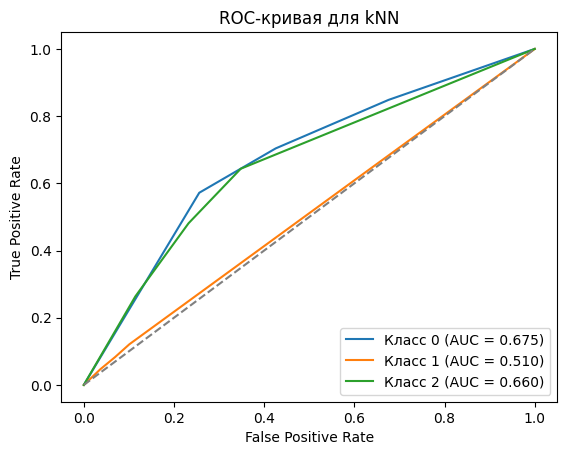

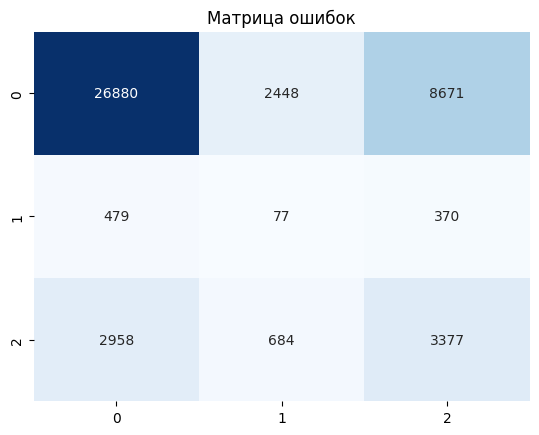

In [29]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Начало обучения kNN")
knn_cfg = best_params['kNN']['GridSearchCV']['best_params']
model_knn = KNeighborsClassifier(**knn_cfg)

model_knn.fit(X_train, y_train)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Модель kNN обучена")

y_pred_knn = model_knn.predict(X_test)
y_prob_knn = model_knn.predict_proba(X_test)
metrics(y_pred_knn, y_prob_knn)

scores_knn = cross_val_score(model_knn, X_train, y_train, cv=3, scoring='accuracy')
print(f'Оценка кросс-валидации: {scores_knn.mean():.4f}')

plt.figure()
for i in range(n_classes):
    fpr_knn, tpr_knn, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    roc_auc_knn = auc(fpr_knn, tpr_knn)
    plt.plot(fpr_knn, tpr_knn, label=f'Класс {i} (AUC = {roc_auc_knn:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для kNN')
plt.legend(loc='lower right')
plt.show()

cm_knn = confusion_matrix(y_test, y_pred_knn)
plt.figure()
sns.heatmap(cm_knn, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

joblib.dump(model_knn, "knn_model.pkl")
model_knn = joblib.load("knn_model.pkl")

#### Custom kNN

In [30]:
class CustomKNN:
    def __init__(self, k=5, p=2):
        self.k = k
        self.p = p

    def fit(self, X, y):
        self.X_train = np.array(X)
        self.y_train = np.array(y)
        return self

    def _distance(self, x1, x2):
        return np.sum(np.abs(x1 - x2)**self.p)**(1/self.p)

    def predict(self, X):
        X = np.array(X)
        return np.array([self._predict_one(x) for x in X])

    def _predict_one(self, x):
        distances = [self._distance(x, x_train) for x_train in self.X_train]
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]
        return Counter(k_nearest_labels).most_common(1)[0][0]

In [34]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Начало обучения Custom kNN")

X_train_custom = X_train_search[:1000]
y_train_custom = y_train_search[:1000]
X_test_custom = X_test[:200]
y_test_custom = y_test[:200]

model_custom_knn = CustomKNN(k=5)
model_custom_knn.fit(X_train_custom, y_train_custom)

y_pred_custom = model_custom_knn.predict(X_test_custom)

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Custom kNN обучен")

print("\nМетрики для Custom kNN (на подвыборке):")
metrics(y_pred_custom, None, y_test_custom)

[19:57:02] Начало обучения Custom kNN
[19:57:03] Custom kNN обучен

Метрики для Custom kNN (на подвыборке):
F1: 0.6099
accuracy: 0.5050
precision: 0.8366
recall: 0.5050
roc_auc_score: N/A (вероятности не предоставлены)


#### NaiveBayes

[19:57:15] Начало обучения Naive Bayes
[19:57:15] Naive Bayes обучена
F1: 0.6886
accuracy: 0.6195
precision: 0.8223
recall: 0.6195
roc_auc_score: 0.7119
Оценка кросс-валидации: 0.4986


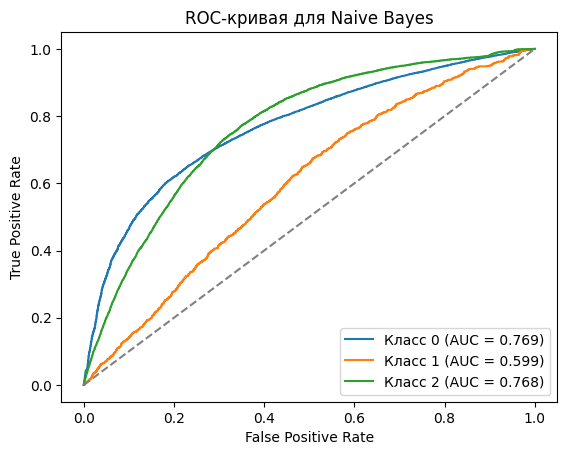

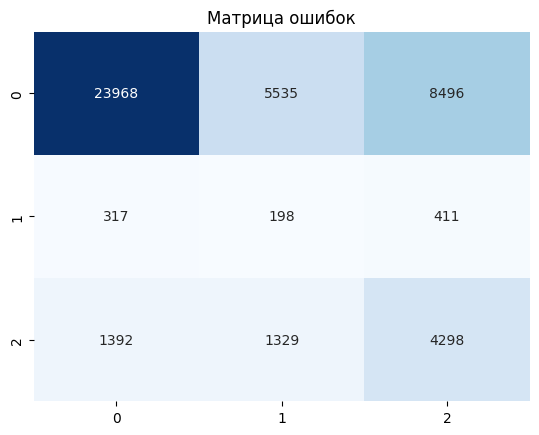

In [35]:

print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Начало обучения Naive Bayes")
nb_cfg = best_params['NaiveBayes']['GridSearchCV']['best_params']
model_nb = GaussianNB(**nb_cfg)

model_nb.fit(X_train, y_train)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Naive Bayes обучена")

y_pred_nb = model_nb.predict(X_test)
y_prob_nb = model_nb.predict_proba(X_test)
metrics(y_pred_nb, y_prob_nb)

scores_nb = cross_val_score(model_nb, X_train, y_train, cv=3, scoring='accuracy', n_jobs=-1)
print(f'Оценка кросс-валидации: {scores_nb.mean():.4f}')

plt.figure()
for i in range(n_classes):
    fpr_nb, tpr_nb, _ = roc_curve(y_test_bin[:, i], y_prob_nb[:, i])
    roc_auc_nb = auc(fpr_nb, tpr_nb)
    plt.plot(fpr_nb, tpr_nb, label=f'Класс {i} (AUC = {roc_auc_nb:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривая для Naive Bayes')
plt.legend(loc='lower right')
plt.show()

cm_nb = confusion_matrix(y_test, y_pred_nb)
plt.figure()
sns.heatmap(cm_nb, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

joblib.dump(model_nb, "naive_bayes_model.pkl")
model_nb = joblib.load("naive_bayes_model.pkl")

#### SVM

[19:57:17] Начало обучения SVM
[19:58:12] SVM обучена
F1: 0.6804
accuracy: 0.6163
precision: 0.7768
recall: 0.6163
roc_auc_score: 0.6457
Оценка кросс-валидации: 0.5874


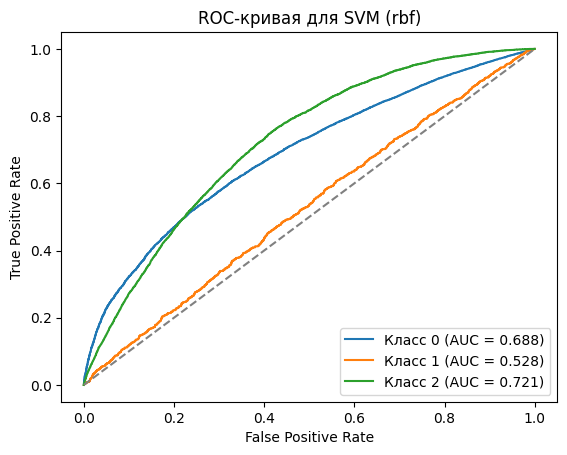

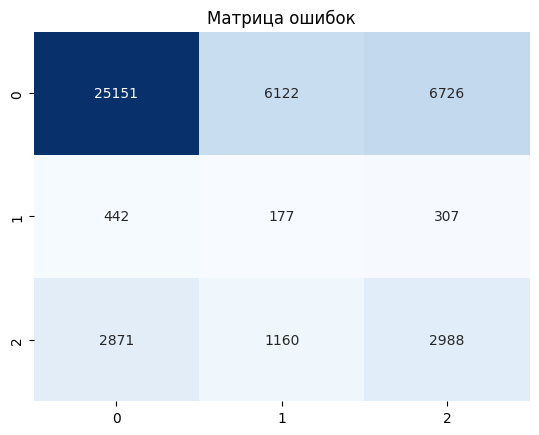

In [36]:
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] Начало обучения SVM")
svm_cfg = best_params['SVM']['Optuna']['best_params']
model_svm = SVC(probability=True, random_state=42, max_iter=10000, cache_size=2000, **svm_cfg)

model_svm.fit(X_train_search, y_train_search)
print(f"[{datetime.datetime.now().strftime('%H:%M:%S')}] SVM обучена")

y_pred_svm = model_svm.predict(X_test)
y_prob_svm = model_svm.predict_proba(X_test)
metrics(y_pred_svm, y_prob_svm)

scores_svm = cross_val_score(model_svm, X_train_search, y_train_search, cv=3, scoring='accuracy', n_jobs=-1)
print(f'Оценка кросс-валидации: {scores_svm.mean():.4f}')

plt.figure()
for i in range(n_classes):
    fpr_svm, tpr_svm, _ = roc_curve(y_test_bin[:, i], y_prob_svm[:, i])
    roc_auc_svm = auc(fpr_svm, tpr_svm)
    plt.plot(fpr_svm, tpr_svm, label=f'Класс {i} (AUC = {roc_auc_svm:.3f})')

plt.plot([0,1], [0,1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title(f"ROC-кривая для SVM ({svm_cfg.get('kernel', 'unknown')})")
plt.legend(loc='lower right')
plt.show()

cm_svm = confusion_matrix(y_test, y_pred_svm)
plt.figure()
sns.heatmap(cm_svm, annot=True, fmt='d', cbar=False, cmap='Blues')
plt.title('Матрица ошибок')
plt.show()

joblib.dump(model_svm, "svm_model.pkl")
model_svm = joblib.load("svm_model.pkl")

In [40]:
def get_row(name, y_true, y_pred):
    return {
        'Классификатор': name,
        'F1 (weighted)': f1_score(y_true, y_pred, average='weighted'),
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, average='weighted'),
        'Recall': recall_score(y_true, y_pred, average='weighted')
    }

final_results = []
final_results.append(get_row('Logistic Regression', y_test, y_pred_lr))
final_results.append(get_row('kNN (sklearn)', y_test, y_pred_knn))
final_results.append(get_row('Naive Bayes', y_test, y_pred_nb))
final_results.append(get_row('SVM', y_test, y_pred_svm))

df_final = pd.DataFrame(final_results)

knn_comp = [
    get_row('kNN Sklearn', y_test_custom, y_pred_knn[:200]),
    get_row('kNN Custom', y_test_custom, y_pred_custom)
]
df_knn_comp = pd.DataFrame(knn_comp)

print("\nТаблица 1: Результаты всех моделей (Hold-out)")
display(df_final.round(4))

print("\nТаблица 2: Сравнение реализации kNN")
display(df_knn_comp.round(4))


Таблица 1: Результаты всех моделей (Hold-out)


,Классификатор,F1 (weighted),Accuracy,Precision,Recall
0,Logistic Regression,0.6982,0.6211,0.8353,0.6211
1,kNN (sklearn),0.7047,0.6602,0.7753,0.6602
2,Naive Bayes,0.6886,0.6195,0.8223,0.6195
3,SVM,0.6804,0.6163,0.7768,0.6163



Таблица 2: Сравнение реализации kNN


,Классификатор,F1 (weighted),Accuracy,Precision,Recall
0,kNN Sklearn,0.7220,0.670,0.8138,0.670
1,kNN Custom,0.6099,0.505,0.8366,0.505
